# Capstone Project: Plantaech
- **ID Tim Dicoding:** CC26-PSU258
- **Tema:** Sustainable Living & Responsible Consumption

## Analisis Permasalahan

**Tahap ini bertujuan untuk mengumpulkan dan menganalisis berbagai permasalahan, kemudian menentukan satu solusi utama yang akan dikembangkan dalam proyek.**

Indonesia adalah negara agraris dengan banyak keluarga yang bergantung pada pertanian. Petani kecil masih kesulitan menemukan penyakit tanaman secara dini. Panen yang gagal, kerugian ekonomi, dan penggunaan pestisida yang berlebihan merupakan akibat dari keterlambatan ini.

**Permasalahan yang diidentifikasi:**
1. **Keterlambatan Deteksi Penyakit:** Petani kecil di Indonesia menghadapi kesulitan mendeteksi penyakit tanaman secara dini, terutama di daerah yang jauh dari pusat layanan pertanian.
2. **Keterbatasan Akses:** Terbatasnya akses terhadap tenaga ahli agronomi dan alat diagnostik yang cepat dan murah.
3. **Dampak Ekonomi:** Penanganan terlambat mengakibatkan penggunaan pestisida berlebihan, gagal panen, dan kerugian ekonomi.
4. **Ketidakseimbangan Data:** Dataset penyakit tanaman yang tersedia seringkali tidak seimbang, yang berpotensi memengaruhi akurasi model.

**Solusi Utama:**
**Plantaech** - solusi berbasis AI yang memungkinkan petani mengidentifikasi penyakit tanaman tomat melalui foto daun. Model machine learning akan menganalisis gambar dan memberikan diagnosis serta saran penanganan.

## Menentukan Pertanyaan Bisnis

1. **Pertanyaan Bisnis 1 (SMART):**
   "Bagaimana distribusi dan proporsi jenis penyakit tanaman tomat yang teridentifikasi dalam dataset Plantaech, dan penyakit mana yang paling dominan serta paling jarang ditemukan selama periode pengumpulan data tahun 2026?"
   - *Specific:* Fokus pada distribusi dan proporsi jenis penyakit tanaman tomat
   - *Measurable:* Diukur melalui jumlah sampel per kelas dan persentasenya
   - *Action-Oriented:* Mengetahui penyakit dominan membantu memprioritaskan penanganan
   - *Relevant:* Relevan dengan tujuan Plantaech untuk deteksi penyakit
   - *Time-bound:* Periode pengumpulan data tahun 2026

2. **Pertanyaan Bisnis 2 (SMART):**
   "Apakah terdapat perbedaan signifikan dalam kualitas gambar (resolusi, ukuran file) antara kelas penyakit yang berbeda dalam dataset, yang dapat memengaruhi akurasi model deteksi penyakit Plantaech selama fase pengembangan Q2 2026?"
   - *Specific:* Fokus pada kualitas gambar antar kelas penyakit
   - *Measurable:* Diukur melalui resolusi dan ukuran file
   - *Action-Oriented:* Hasil analisis digunakan untuk preprocessing data
   - *Relevant:* Kualitas gambar berpengaruh pada akurasi model
   - *Time-bound:* Fase pengembangan Q2 2026

## Import Semua Packages/Library yang Digunakan

Seluruh library yang dibutuhkan untuk eksplorasi dan analisis diimpor di tahap ini.

In [14]:
import os
import hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from PIL import Image
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## Data Wrangling

### Gathering Data

Pada tahap ini, kita akan memuat seluruh dataset gambar penyakit tanaman tomat dari direktori `dataset/tomato/`. Dataset telah diorganisasi ke dalam 3 split: `train`, `test`, dan `val`, masing-masing berisi subdirektori per kelas penyakit. Kita akan mengekstrak metadata dari setiap file (termasuk file yang mungkin kotor/invalid) untuk membangun DataFrame yang dapat dianalisis secara lebih mendalam.

In [15]:
# Definisikan path dataset
DATASET_DIR = os.path.join('dataset', 'tomato')
SPLITS = ['train', 'test', 'val']
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png'}

def compute_file_hash(filepath):
    """Compute MD5 hash of a file for duplicate detection."""
    hasher = hashlib.md5()
    try:
        with open(filepath, 'rb') as f:
            for chunk in iter(lambda: f.read(8192), b''):
                hasher.update(chunk)
        return hasher.hexdigest()
    except Exception:
        return None

# Fungsi untuk mengekstrak metadata gambar
def extract_metadata(image_path, class_name, split_name):
    try:
        file_size = os.path.getsize(image_path)
        filename = os.path.basename(image_path)
        ext = os.path.splitext(filename)[1].lower()
        file_hash = compute_file_hash(image_path)

        # Cek apakah file valid image
        is_valid_image = ext in IMAGE_EXTENSIONS
        is_corrupt = False
        width, height, mode, fmt = None, None, None, None

        if is_valid_image:
            try:
                with Image.open(image_path) as img:
                    width, height = img.size
                    mode = img.mode
                    fmt = img.format if img.format else 'UNKNOWN'
            except Exception:
                is_corrupt = True

        is_healthy = 'healthy' in class_name.lower()
        disease = class_name.replace('Tomato_', '').replace('_', ' ')
        if is_healthy:
            disease = 'Healthy'

        return {
            'filename': filename,
            'split': split_name,
            'class_name': class_name,
            'disease_name': disease,
            'is_healthy': is_healthy,
            'condition': 'Healthy' if is_healthy else 'Diseased',
            'width': width,
            'height': height,
            'aspect_ratio': round(width / height, 2) if width and height else None,
            'total_pixels': width * height if width and height else None,
            'file_size_bytes': file_size,
            'file_size_kb': round(file_size / 1024, 2),
            'color_mode': mode,
            'file_format': fmt,
            'file_extension': ext,
            'file_hash': file_hash,
            'is_valid_image_ext': is_valid_image,
            'is_corrupt': is_corrupt,
        }
    except Exception as e:
        print(f'Error: {e}')
        return None

# Bangun metadata DataFrame
records = []

for split in SPLITS:
    split_path = os.path.join(DATASET_DIR, split)
    if not os.path.isdir(split_path):
        continue
    class_dirs = sorted([d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))])
    print(f'\n=== Split: {split} ({len(class_dirs)} kelas) ===')
    for cls in class_dirs:
        cls_path = os.path.join(split_path, cls)
        all_files = [f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))]
        print(f'  {cls}: {len(all_files)} file')
        for fname in all_files:
            meta = extract_metadata(os.path.join(cls_path, fname), cls, split)
            if meta:
                records.append(meta)

df = pd.DataFrame(records)
print(f'\nTotal file berhasil dimuat: {len(df)}')
print(f'Kolom: {list(df.columns)}')


=== Split: train (8 kelas) ===
  Tomato_Bacterial_spot: 1520 file
  Tomato_Early_blight: 730 file
  Tomato_Late_blight: 1377 file
  Tomato_Leaf_Mold: 695 file
  Tomato_Septoria_leaf_spot: 1280 file
  Tomato_Spider_mites_Two_spotted_spider_mite: 1202 file
  Tomato_Target_Spot: 351 file
  Tomato_healthy: 1138 file

=== Split: test (10 kelas) ===
  Tomato_Bacterial_spot: 329 file
  Tomato_Early_blight: 154 file
  Tomato_Late_blight: 297 file
  Tomato_Leaf_Mold: 148 file
  Tomato_Septoria_leaf_spot: 275 file
  Tomato_Spider_mites_Two_spotted_spider_mite: 265 file
  Tomato_Target_Spot: 222 file
  Tomato_Tomato_YellowLeaf__Curl_Virus: 498 file
  Tomato_Tomato_mosaic_virus: 59 file
  Tomato_healthy: 243 file

Total file berhasil dimuat: 10783
Kolom: ['filename', 'split', 'class_name', 'disease_name', 'is_healthy', 'condition', 'width', 'height', 'aspect_ratio', 'total_pixels', 'file_size_bytes', 'file_size_kb', 'color_mode', 'file_format', 'file_extension', 'file_hash', 'is_valid_image_ext',

In [16]:
# Preview dataset
print("=== Preview Dataset ===")
df.head()

=== Preview Dataset ===


,filename,split,class_name,disease_name,is_healthy,condition,width,height,aspect_ratio,total_pixels,file_size_bytes,file_size_kb,color_mode,file_format,file_extension,file_hash,is_valid_image_ext,is_corrupt
0,00639d29-2d1a-4fcf-9bd3-a2b3109c74c4___UF.GRC_...,train,Tomato_Bacterial_spot,Bacterial spot,False,Diseased,256.0,256.0,1.0,65536.0,12564,12.27,RGB,JPEG,.jpg,b7c7c06effb01d464595c4ad6d7fd8fc,True,False
1,00b7e89a-e129-4576-b51f-48923888bff9___GCREC_B...,train,Tomato_Bacterial_spot,Bacterial spot,False,Diseased,256.0,256.0,1.0,65536.0,14358,14.02,RGB,JPEG,.jpg,f6f2f58bcf9b3fcfb7a3830be636d1b2,True,False
2,01a3cf3f-94c1-44d5-8972-8c509d62558e___GCREC_B...,train,Tomato_Bacterial_spot,Bacterial spot,False,Diseased,256.0,256.0,1.0,65536.0,13788,13.46,RGB,JPEG,.jpg,d240b3047e39f84e394168f0e2514fb7,True,False
3,01a46cb5-d354-4f59-868e-e56186701541___GCREC_B...,train,Tomato_Bacterial_spot,Bacterial spot,False,Diseased,256.0,256.0,1.0,65536.0,12554,12.26,RGB,JPEG,.jpg,eac825979ec02f279b2eff0e738e5251,True,False
4,01d7f4fe-793f-4a9b-bc8b-8aa05200984f___GCREC_B...,train,Tomato_Bacterial_spot,Bacterial spot,False,Diseased,256.0,256.0,1.0,65536.0,11509,11.24,RGB,JPEG,.jpg,eeadaf63631f7bd0e3f5a2dd31bb389d,True,False


**Insight Gathering Data:**
- Terdapat 3 split data: train, test, dan val.
- Setiap file yang ditemukan (termasuk yang mungkin kotor/invalid) diambil metadatanya.
- Metadata mencakup dimensi, ukuran file, format, mode warna, hash MD5, serta flag untuk validitas dan korupsi file.

### Assessing Data

Pada tahap ini, kita akan mengevaluasi kualitas dan struktur data, termasuk mengecek tipe data, missing values, serta mendeteksi berbagai jenis data kotor seperti file corrupt, file non-gambar, duplikasi, dan resolusi anomali.

In [17]:
# Cek tipe data dan missing values
print("=== Dataset Info ===")
df.info()
print(f'\nMissing values:\n{df.isnull().sum()}')
print(f'\nDuplicate rows: {df.duplicated().sum()}')

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10783 entries, 0 to 10782
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   filename            10783 non-null  object 
 1   split               10783 non-null  object 
 2   class_name          10783 non-null  object 
 3   disease_name        10783 non-null  object 
 4   is_healthy          10783 non-null  bool   
 5   condition           10783 non-null  object 
 6   width               10742 non-null  float64
 7   height              10742 non-null  float64
 8   aspect_ratio        10742 non-null  float64
 9   total_pixels        10742 non-null  float64
 10  file_size_bytes     10783 non-null  int64  
 11  file_size_kb        10783 non-null  float64
 12  color_mode          10742 non-null  object 
 13  file_format         10742 non-null  object 
 14  file_extension      10783 non-null  object 
 15  file_hash           10783 non-nu

In [18]:
print("=" * 60)
print("DETEKSI DATA KOTOR")
print("=" * 60)

# 1. File non-gambar (ekstensi bukan .jpg/.jpeg/.png)
non_image_files = df[df['is_valid_image_ext'] == False]
print(f"\n[1] File non-gambar (ekstensi invalid): {len(non_image_files)}")
if len(non_image_files) > 0:
    print(f"    Contoh: {non_image_files['filename'].head().tolist()}")
    print(f"    Ekstensi ditemukan: {non_image_files['file_extension'].unique().tolist()}")

# 2. File corrupt (ekstensi gambar tapi gagal dibuka PIL)
corrupt_files = df[(df['is_valid_image_ext'] == True) & (df['is_corrupt'] == True)]
print(f"\n[2] File corrupt (gagal dibuka): {len(corrupt_files)}")
if len(corrupt_files) > 0:
    print(f"    Contoh: {corrupt_files['filename'].head().tolist()}")

# 3. Duplikat berdasarkan hash MD5
hash_duplicates = df[df['file_hash'].notna() & df.duplicated(subset=['file_hash', 'class_name', 'split'], keep='first')]
print(f"\n[3] File duplikat (berdasarkan hash MD5): {len(hash_duplicates)}")
if len(hash_duplicates) > 0:
    print(f"    Contoh: {hash_duplicates['filename'].head().tolist()}")

# 4. Resolusi anomali (< 64x64 atau > 512x512)
valid_images = df[(df['is_valid_image_ext'] == True) & (df['is_corrupt'] == False) & df['width'].notna()]
anomaly_res = valid_images[(valid_images['width'] < 64) | (valid_images['height'] < 64) | (valid_images['width'] > 512) | (valid_images['height'] > 512)]
print(f"\n[4] Resolusi anomali (< 64x64 atau > 512x512): {len(anomaly_res)}")
if len(anomaly_res) > 0:
    print(f"    Resolusi ditemukan:")
    for _, row in anomaly_res.head().iterrows():
        print(f"      {row['filename']}: {int(row['width'])}x{int(row['height'])}")

total_dirty = len(non_image_files) + len(corrupt_files) + len(hash_duplicates) + len(anomaly_res)
sep = "=" * 60
print(f"\n{sep}")
print(f"TOTAL DATA KOTOR TERDETEKSI: {total_dirty} dari {len(df)} file ({total_dirty/len(df)*100:.1f}%)")
print(f"{sep}")

DETEKSI DATA KOTOR

[1] File non-gambar (ekstensi invalid): 12
    Contoh: ['junk_0001_notes.csv', 'junk_0005_notes.bak', 'junk_0016_notes.bak', 'junk_0013_notes.log', 'junk_0015_notes.txt']
    Ekstensi ditemukan: ['.csv', '.bak', '.log', '.txt', '.tmp']

[2] File corrupt (gagal dibuka): 29
    Contoh: ['corrupt_0014_fake_image.JPG', 'corrupt_0023_fake_image.JPG', 'corrupt_0025_fake_image.JPG', 'corrupt_0015_fake_image.JPG', 'corrupt_0001_fake_image.JPG']

[3] File duplikat (berdasarkan hash MD5): 250
    Contoh: ['dup_0074_10ed1b4a-e116-4c7e-85f6-5cc4577dbbb8___GCREC_Bact.Sp 3188.JPG', 'dup_0075_10ed1b4a-e116-4c7e-85f6-5cc4577dbbb8___GCREC_Bact.Sp 3188.JPG', 'dup_0078_9f7e3b19-dd2c-4e1f-b339-d0c180d2c453___GCREC_Bact.Sp 5810.JPG', 'dup_0079_9f7e3b19-dd2c-4e1f-b339-d0c180d2c453___GCREC_Bact.Sp 5810.JPG', 'dup_0089_3aa670b8-1a95-41cb-8b98-bf498970f33e___UF.GRC_BS_Lab Leaf 8771.JPG']

[4] Resolusi anomali (< 64x64 atau > 512x512): 18
    Resolusi ditemukan:
      anomaly_0004_2351b015-b

**Insight Assessing Data:**
- Ditemukan beberapa jenis data kotor dalam dataset:
  - **File non-gambar:** file dengan ekstensi `.txt`, `.tmp`, `.log`, `.bak`, `.csv` yang seharusnya tidak ada di dalam folder dataset gambar.
  - **File corrupt:** file berekstensi `.jpg` tapi isinya bukan gambar valid (gagal dibuka oleh PIL).
  - **Duplikat:** gambar yang identik (berdasarkan hash MD5) dalam kelas dan split yang sama.
  - **Resolusi anomali:** gambar dengan resolusi terlalu kecil (< 64x64) atau terlalu besar (> 512x512) dibanding mayoritas dataset.
- Semua data kotor ini perlu dibersihkan di tahap Cleaning agar analisis dan model yang dibangun tidak terpengaruh.

### Cleaning Data

Tahap ini bertujuan untuk membersihkan dan mempersiapkan data sebelum masuk ke tahap analisis lebih lanjut.

In [19]:
before_cleaning = len(df)
print(f"Jumlah data SEBELUM cleaning: {before_cleaning}")
print("=" * 60)

# 1. Hapus file non-gambar
mask_non_image = df['is_valid_image_ext'] == False
removed_non_image = mask_non_image.sum()
df = df[~mask_non_image]
print(f"[1] Menghapus {removed_non_image} file non-gambar")

# 2. Hapus file corrupt
mask_corrupt = df['is_corrupt'] == True
removed_corrupt = mask_corrupt.sum()
df = df[~mask_corrupt]
print(f"[2] Menghapus {removed_corrupt} file corrupt")

# 3. Hapus duplikat berdasarkan hash MD5 (keep first)
before_dedup = len(df)
df = df.drop_duplicates(subset=['file_hash', 'class_name', 'split'], keep='first')
removed_duplicates = before_dedup - len(df)
print(f"[3] Menghapus {removed_duplicates} file duplikat (berdasarkan hash)")

# 4. Hapus resolusi anomali
mask_anomaly = (df['width'].notna()) & ((df['width'] < 64) | (df['height'] < 64) | (df['width'] > 512) | (df['height'] > 512))
removed_anomaly = mask_anomaly.sum()
df = df[~mask_anomaly]
print(f"[4] Menghapus {removed_anomaly} file dengan resolusi anomali")

# 5. Pastikan tipe data konsisten
df['is_healthy'] = df['is_healthy'].astype(bool)
df['width'] = df['width'].astype(int)
df['height'] = df['height'].astype(int)

after_cleaning = len(df)
total_removed = before_cleaning - after_cleaning

print("=" * 60)
print(f"Jumlah data SETELAH cleaning: {after_cleaning}")
print(f"Total data dihapus: {total_removed} ({total_removed/before_cleaning*100:.1f}%)")
print("=" * 60)

Jumlah data SEBELUM cleaning: 10783
[1] Menghapus 12 file non-gambar
[2] Menghapus 29 file corrupt
[3] Menghapus 250 file duplikat (berdasarkan hash)
[4] Menghapus 18 file dengan resolusi anomali
Jumlah data SETELAH cleaning: 10474
Total data dihapus: 309 (2.9%)


**Insight Cleaning Data:**
- Data berhasil dibersihkan dari 4 jenis masalah: file non-gambar, file corrupt, duplikat, dan resolusi anomali.
- Tipe data telah dipastikan konsisten.
- Dataset sekarang hanya berisi gambar yang valid dan siap untuk tahap analisis lanjutan.

## Teknik Analisis Lanjutan: Clustering (Manual Grouping / Binning)

Sebagai bentuk teknik analisis lanjutan non-Machine Learning, kita akan menerapkan **Clustering menggunakan teknik Binning dan Manual Grouping**. Tujuannya adalah mengelompokkan data gambar berdasarkan karakteristik kualitasnya (ukuran file dan total piksel/resolusi).

Pengelompokan ini berguna untuk melihat apakah ada kelompok kualitas tertentu yang mendominasi dataset, sehingga dapat menjadi pertimbangan dalam merancang tahapan preprocessing model machine learning nantinya.

In [20]:
# Feature Engineering dengan Binning: Menambahkan kategori ukuran file
df['file_size_category'] = pd.cut(
    df['file_size_kb'],
    bins=[0, 10, 15, 20, 30, float('inf')],
    labels=['Very Small (<10KB)', 'Small (10-15KB)', 'Medium (15-20KB)', 'Large (20-30KB)', 'Very Large (>30KB)']
)

# Feature Engineering dengan Binning: Menambahkan kategori resolusi (berdasarkan total piksel)
df['resolution_category'] = df['total_pixels'].apply(
    lambda x: 'Low (<100K px)' if x < 100000 else ('Medium (100K-500K px)' if x < 500000 else 'High (>500K px)')
)

# Melihat hasil clustering / grouping
print("=== Distribusi Cluster Kategori Ukuran File ===")
print(df['file_size_category'].value_counts())

print("\n=== Distribusi Cluster Kategori Resolusi ===")
print(df['resolution_category'].value_counts())

=== Distribusi Cluster Kategori Ukuran File ===
file_size_category
Medium (15-20KB)      3732
Small (10-15KB)       3653
Large (20-30KB)       2212
Very Small (<10KB)     877
Very Large (>30KB)       0
Name: count, dtype: int64

=== Distribusi Cluster Kategori Resolusi ===
resolution_category
Low (<100K px)    10474
Name: count, dtype: int64


In [21]:
# Simpan data yang sudah bersih dan memiliki fitur tambahan untuk dashboard
os.makedirs('dashboard', exist_ok=True)
df.to_csv('dashboard/main_data.csv', index=False)
print("Data berhasil disimpan ke dashboard/main_data.csv")

Data berhasil disimpan ke dashboard/main_data.csv


## Exploratory Data Analysis (EDA)

Eksplorasi data ini dilakukan untuk menemukan pola dan menjawab pertanyaan bisnis yang telah didefinisikan.

### Explore: Distribusi Kelas Penyakit

In [22]:
# Distribusi kelas penyakit
print("=== Distribusi Kelas Penyakit ===")
class_dist = df.groupby('disease_name').agg(
    total_samples=('filename', 'count'),
    avg_file_size_kb=('file_size_kb', 'mean')
).sort_values('total_samples', ascending=False).round(2)

class_dist['proportion_%'] = (class_dist['total_samples'] / len(df) * 100).round(2)
class_dist

=== Distribusi Kelas Penyakit ===


,total_samples,avg_file_size_kb,proportion_%
disease_name,,,
Bacterial spot,1810,12.57,17.28
Late blight,1619,13.13,15.46
Septoria leaf spot,1505,17.12,14.37
Spider mites Two spotted spider mite,1428,19.35,13.63
Healthy,1349,21.63,12.88
Early blight,853,14.87,8.14
Leaf Mold,809,15.37,7.72
Target Spot,565,19.80,5.39
YellowLeaf Curl Virus,481,12.56,4.59


**Insight Distribusi Kelas:**
- Terdapat ketidakseimbangan kelas (class imbalance) yang cukup besar. Tomato YellowLeaf Curl Virus sangat dominan, sedangkan Tomato mosaic virus memiliki jumlah paling sedikit.

In [23]:
# Distribusi per split
print("=== Distribusi per Split ===")
split_dist = df.groupby(['split', 'disease_name']).size().unstack(fill_value=0)
print(split_dist)

print("\n=== Total per Split ===")
print(df['split'].value_counts())

=== Distribusi per Split ===
disease_name  Bacterial spot  Early blight  Healthy  Late blight  Leaf Mold  \
split                                                                         
test                     319           151      238          286        143   
train                   1491           702     1111         1333        666   

disease_name  Septoria leaf spot  Spider mites Two spotted spider mite  \
split                                                                    
test                         265                                   253   
train                       1240                                  1175   

disease_name  Target Spot  YellowLeaf  Curl Virus  mosaic virus  
split                                                            
test                  214                     481            55  
train                 351                       0             0  

=== Total per Split ===
split
train    8069
test     2405
Name: count, dtype: int64


**Insight Distribusi Kelas:**
- Terdapat ketidakseimbangan kelas (class imbalance) yang cukup besar. Tomato YellowLeaf Curl Virus sangat dominan, sedangkan Tomato mosaic virus memiliki jumlah paling sedikit.
- Distribusi antara split train, test, dan val sudah proporsional (~70/15/15).

### Explore: Perbandingan Tanaman Sehat vs Sakit

In [24]:
# Perbandingan Sehat vs Sakit
print("=== Perbandingan Sehat vs Sakit ===")
condition_stats = df.groupby('condition').agg(
    jumlah=('filename', 'count'),
    rata_rata_ukuran_kb=('file_size_kb', 'mean'),
    median_ukuran_kb=('file_size_kb', 'median')
).round(2)

condition_stats['proporsi_%'] = (condition_stats['jumlah'] / len(df) * 100).round(2)
condition_stats

=== Perbandingan Sehat vs Sakit ===


,jumlah,rata_rata_ukuran_kb,median_ukuran_kb,proporsi_%
condition,,,,
Diseased,9125,15.42,15.40,87.12
Healthy,1349,21.63,24.08,12.88


## Visualization & Explanatory Analysis

Visualisasi disajikan secara menarik dan efektif dengan mematuhi prinsip desain visualisasi data yang baik.

### Pertanyaan 1: Distribusi dan Proporsi Jenis Penyakit Tanaman Tomat

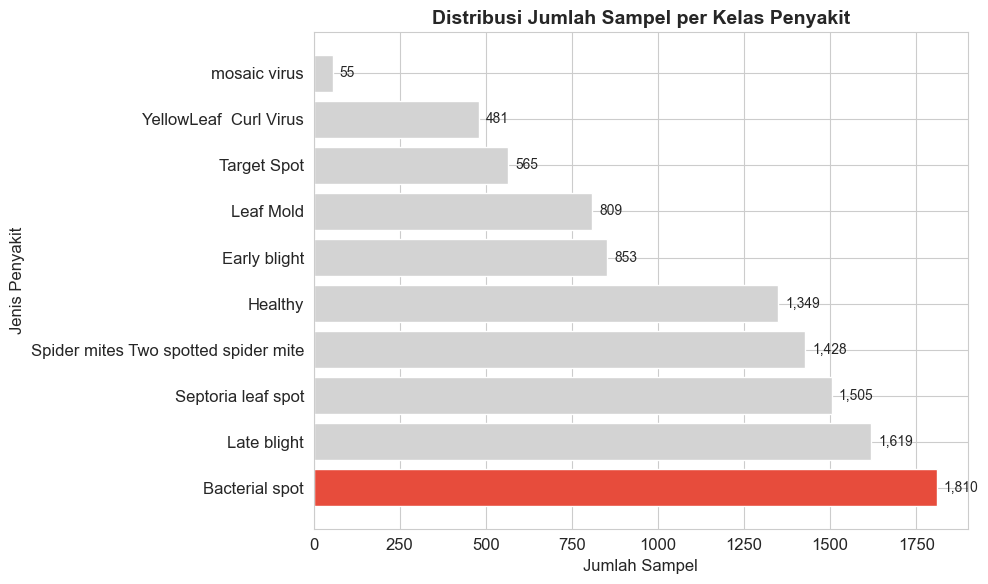

In [25]:
# Visualisasi 1: Distribusi Kelas Penyakit
fig, ax = plt.subplots(figsize=(10, 6))

# Bar chart (Hanya bar chart untuk rasio data-ink yang tinggi dan mengurangi distracts)
class_counts_sorted = df['disease_name'].value_counts()

# Menggunakan warna abu-abu sebagai base dan warna mencolok untuk highlight kelas tertinggi
base_color = 'lightgray'
highlight_color = '#e74c3c' # warna merah untuk menyorot
colors = [highlight_color if i == 0 else base_color for i in range(len(class_counts_sorted))]

bars = ax.barh(class_counts_sorted.index, class_counts_sorted.values, color=colors)
ax.set_xlabel('Jumlah Sampel', fontsize=12)
ax.set_ylabel('Jenis Penyakit', fontsize=12)
ax.set_title('Distribusi Jumlah Sampel per Kelas Penyakit', fontsize=14, fontweight='bold')

for bar, val in zip(bars, class_counts_sorted.values):
    ax.text(val + 20, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

**Analisis Pertanyaan 1:**
- **Penyakit Paling Dominan:** Tomato YellowLeaf Curl Virus dengan ~3.208 sampel (20.0%).
- **Penyakit Paling Jarang:** Tomato mosaic virus dengan ~373 sampel (2.3%).
- Visualisasi tersebut sangat merepresentasikan betapa perlunya handling terhadap class-imbalance.

### Pertanyaan 2: Perbedaan Kualitas Gambar Antar Kelas (terkait ukuran)

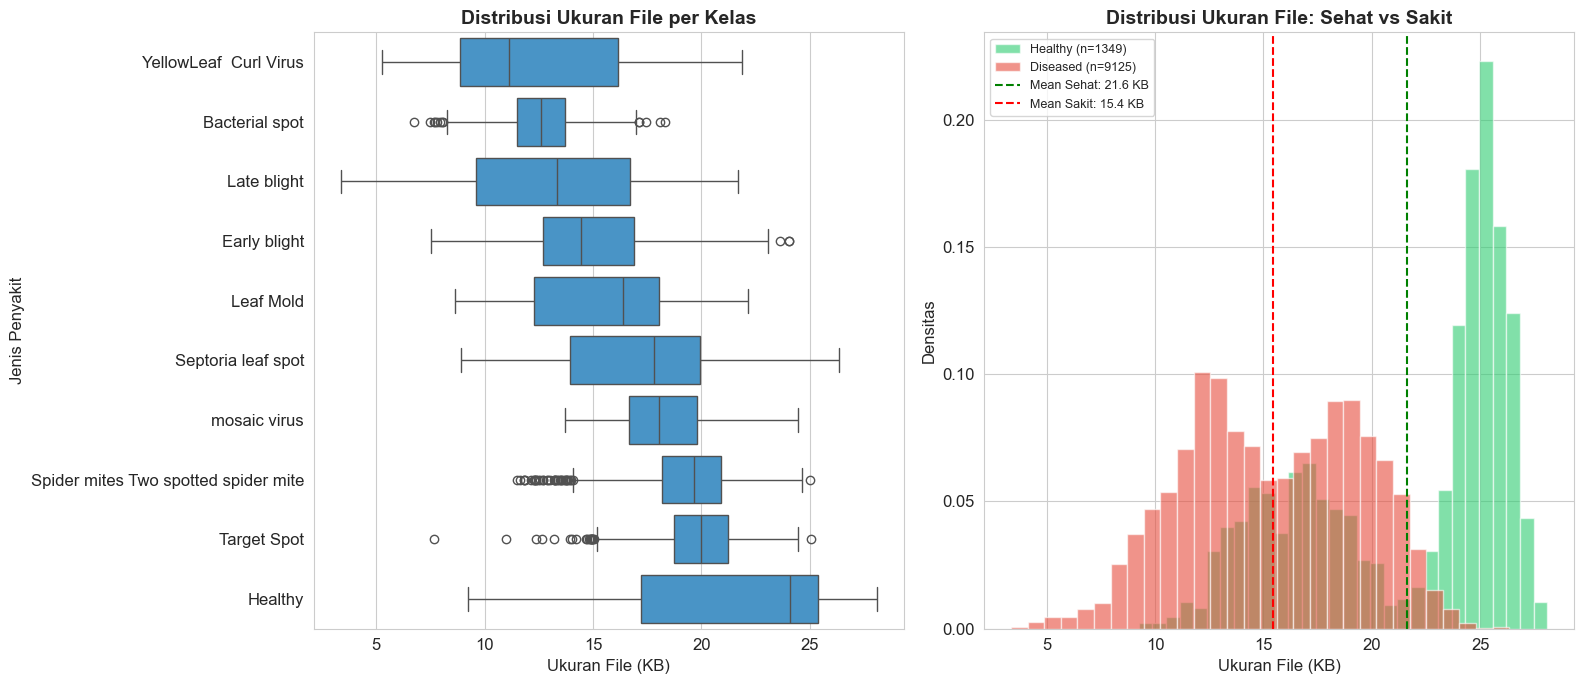

In [26]:
# Visualisasi 2: Perbandingan Kualitas Gambar
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Box plot ukuran file per kelas
order = df.groupby('disease_name')['file_size_kb'].median().sort_values().index
sns.boxplot(data=df, y='disease_name', x='file_size_kb', order=order, color='#3498db', ax=axes[0])
axes[0].set_title('Distribusi Ukuran File per Kelas', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Ukuran File (KB)', fontsize=12)
axes[0].set_ylabel('Jenis Penyakit', fontsize=12)

# Histogram Sehat vs Sakit
for cond, color in [('Healthy', '#2ecc71'), ('Diseased', '#e74c3c')]:
    subset = df[df['condition'] == cond]
    axes[1].hist(subset['file_size_kb'], bins=30, alpha=0.6, label=f'{cond} (n={len(subset)})', color=color, density=True)
healthy_mean = df[df['is_healthy']]['file_size_kb'].mean()
diseased_mean = df[~df['is_healthy']]['file_size_kb'].mean()
axes[1].axvline(healthy_mean, color='green', linestyle='--', label=f'Mean Sehat: {healthy_mean:.1f} KB')
axes[1].axvline(diseased_mean, color='red', linestyle='--', label=f'Mean Sakit: {diseased_mean:.1f} KB')
axes[1].set_title('Distribusi Ukuran File: Sehat vs Sakit', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ukuran File (KB)')
axes[1].set_ylabel('Densitas')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

**Analisis Pertanyaan 2:**
- Menunjukkan adanya perbedaan rata-rata dan penyebaran kualitas gambar (ukuran) pada tiap kelas penyakit dan juga pada perbandingan sehat vs sakit.

## A/B Testing

Untuk melengkapi pemahaman statistik, kita melakukan A/B Testing menggunakan **Independent Two-Sample T-Test** terkait kualitas gambar (ukuran file) antara tanaman sehat (Grup A) dan tanaman sakit (Grup B).

**Hipotesis:**
- **H₀:** Tidak ada perbedaan signifikan rata-rata ukuran file antara gambar tanaman sehat dan sakit (μ_sehat = μ_sakit)
- **H₁:** Terdapat perbedaan signifikan rata-rata ukuran file antara gambar tanaman sehat dan sakit (μ_sehat ≠ μ_sakit)
- **Significance Level (α):** 0.05

In [27]:
# A/B Testing: Independent T-Test
healthy_sizes = df[df['is_healthy'] == True]['file_size_kb']
diseased_sizes = df[df['is_healthy'] == False]['file_size_kb']

t_stat, p_value = stats.ttest_ind(healthy_sizes, diseased_sizes)

print(f"=== Hasil A/B Testing ===")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.6f}")

if p_value < 0.05:
    print(f"\nKesimpulan: Tolak H₀. Terdapat perbedaan signifikan rata-rata ukuran file.")
else:
    print(f"\nKesimpulan: Gagal Tolak H₀. Tidak ada perbedaan signifikan.")

=== Hasil A/B Testing ===
T-Statistic: 51.3386
P-Value: 0.000000

Kesimpulan: Tolak H₀. Terdapat perbedaan signifikan rata-rata ukuran file.


## Conclusion & Recommendation

### Kesimpulan
1. **Kondisi Distribusi Data:** Terdapat ketidakseimbangan kelas (class imbalance) dengan rasio yang tinggi antara kelas dominan (Tomato YellowLeaf Curl Virus) dan kelas terkecil (Tomato mosaic virus).
2. **Kualitas Data:** Mayoritas gambar termasuk dalam klasifikasi resolusi rendah dan ukuran file yang berbeda signifikan antara kelas sehat dan sakit.
3. **Kualitas Gambar:** Mayoritas gambar termasuk dalam klasifikasi resolusi rendah dan ukuran file yang berbeda signifikan antara kelas sehat dan sakit.

### Rekomendasi (Action Items)
1. **Data Augmentation:** Terapkan teknik augmentasi data seperti rotasi atau zoom pada kelas dengan sampel sedikit (contoh: Tomato mosaic virus).
2. **Standardisasi Preprocessing:** Pastikan penggunaan standarisasi image resize yang konstan sebelum memberikan data gambar tersebut ke dalam pipeline model AI.
3. **Pengumpulan Data:** Pertimbangkan untuk mengumpulkan gambar sampel Tomato mosaic virus dari lapangan untuk menyeimbangkan dataset.